In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [72]:
df = pd.read_excel(
    "../data/raw/sales.xlsx"
)

In [73]:
print(df.head())
print(df.info())

        State       Date      Total   Category
0     Alabama 2019-12-01  109574036  Beverages
1     Arizona 2019-12-01  109101595  Beverages
2    Arkansas 2019-12-01   58049432  Beverages
3  California 2019-12-01  444766891  Beverages
4    Colorado 2019-12-01   89816716  Beverages
<class 'pandas.DataFrame'>
RangeIndex: 8084 entries, 0 to 8083
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   State     8084 non-null   str           
 1   Date      8084 non-null   datetime64[us]
 2   Total     8084 non-null   int64         
 3   Category  8084 non-null   str           
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 252.8 KB
None


In [74]:
print(df.isnull().sum())

State       0
Date        0
Total       0
Category    0
dtype: int64


In [75]:
df["Date"] = pd.to_datetime(df["Date"])

In [76]:
df["State"] = df["State"].str.strip()

In [77]:
print(df.shape)

print(df.columns)

print(df["State"].nunique())

print(df["Date"].min())
print(df["Date"].max())

(8084, 4)
Index(['State', 'Date', 'Total', 'Category'], dtype='str')
43
2019-10-06 00:00:00
2023-05-07 00:00:00


In [78]:
sample_state = df[df["State"] == "California"]

print(
    sample_state["Date"]
    .sort_values()
    .diff()
    .value_counts()
)

Date
7 days    187
Name: count, dtype: int64


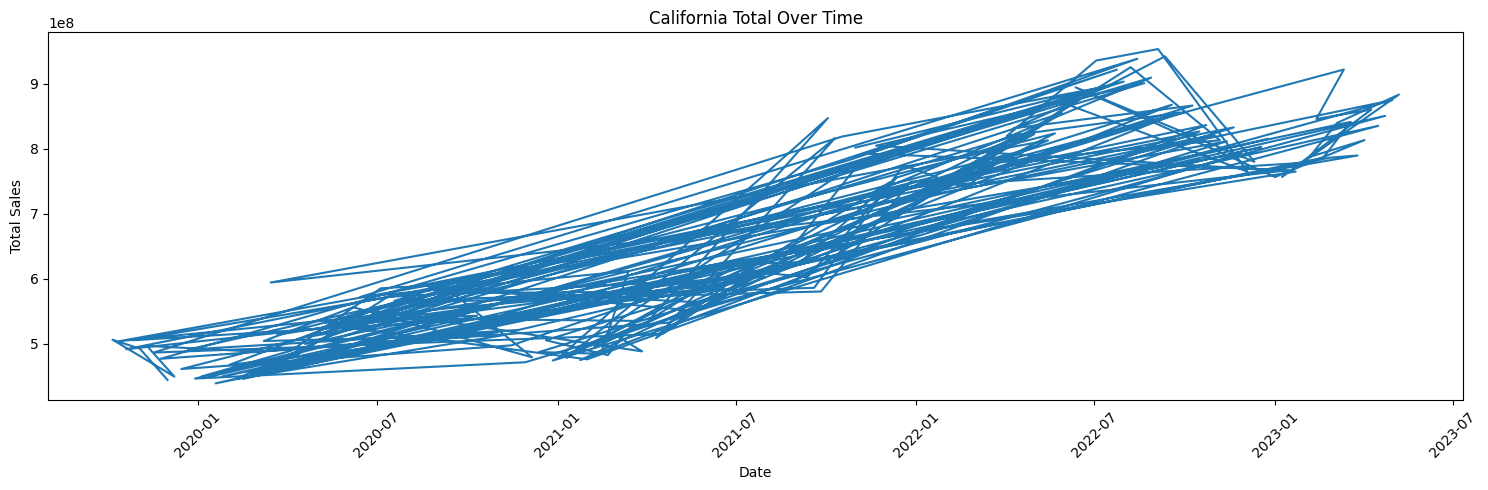

In [79]:
state_df = df[df["State"] == "California"]

plt.figure(figsize=(15,5))

plt.plot(
    state_df["Date"],
    state_df["Total"]
)

plt.title("California Total Over Time")

plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [80]:
print(state_df.head())

          State       Date      Total   Category
3    California 2019-12-01  444766891  Beverages
46   California 2019-11-03  492597099  Beverages
89   California 2019-10-06  506587724  Beverages
132  California 2019-12-08  449865324  Beverages
175  California 2019-11-10  497063952  Beverages


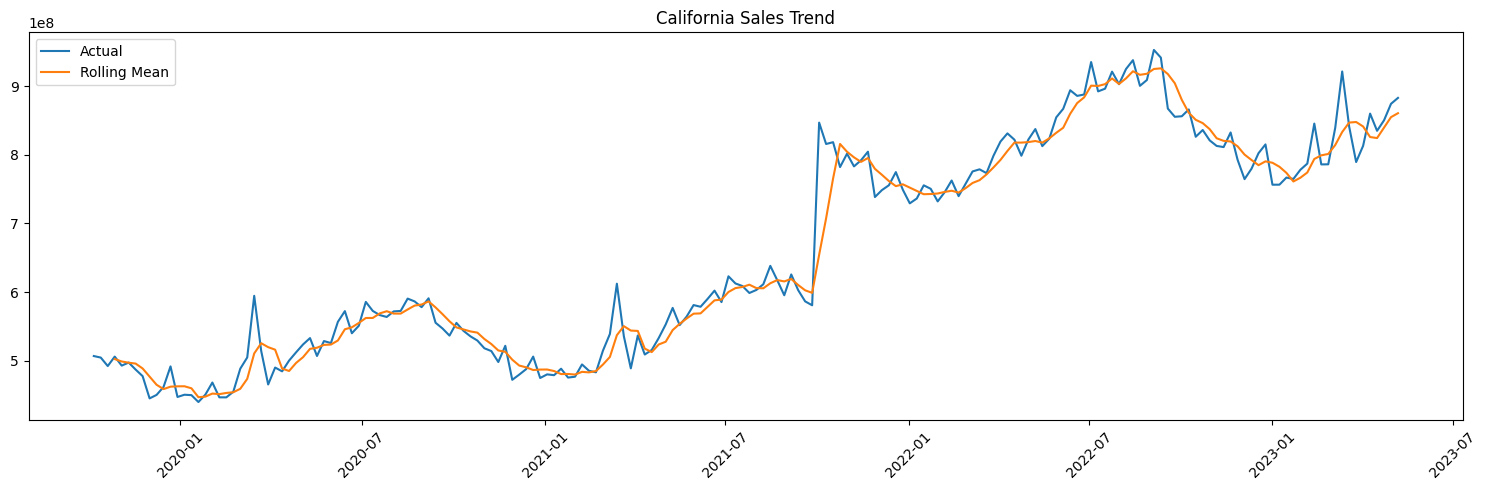

In [81]:
state_df = state_df.sort_values("Date")

state_df["rolling_mean"] = (
    state_df["Total"]
    .rolling(window=4)
    .mean()
)

plt.figure(figsize=(15,5))

plt.plot(
    state_df["Date"],
    state_df["Total"],
    label="Actual"
)

plt.plot(
    state_df["Date"],
    state_df["rolling_mean"],
    label="Rolling Mean"
)

plt.legend()

plt.title("California Sales Trend")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [82]:
print(df.head())

        State       Date      Total   Category
0     Alabama 2019-12-01  109574036  Beverages
1     Arizona 2019-12-01  109101595  Beverages
2    Arkansas 2019-12-01   58049432  Beverages
3  California 2019-12-01  444766891  Beverages
4    Colorado 2019-12-01   89816716  Beverages


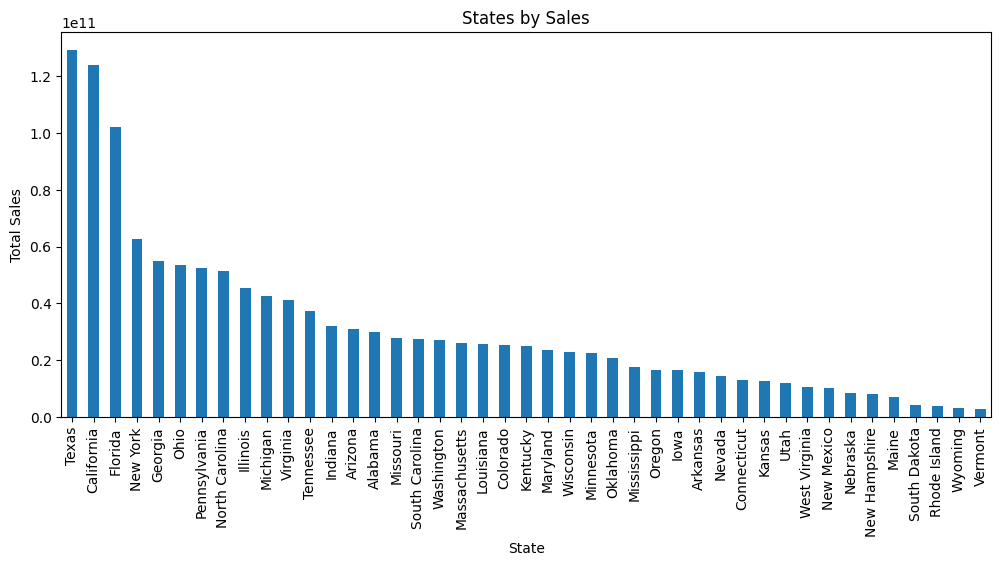

In [85]:
top_states = (
    df.groupby("State")["Total"]
    .sum()
    .sort_values(ascending=False)
    
)

top_states.plot(kind="bar", figsize=(12,5))

plt.title("States by Sales")

plt.ylabel("Total Sales")

plt.show()

In [86]:
df.drop(columns=["Category"], inplace=True)

In [87]:
print(df.head())

print(df.info())

print(df.describe())

        State       Date      Total
0     Alabama 2019-12-01  109574036
1     Arizona 2019-12-01  109101595
2    Arkansas 2019-12-01   58049432
3  California 2019-12-01  444766891
4    Colorado 2019-12-01   89816716
<class 'pandas.DataFrame'>
RangeIndex: 8084 entries, 0 to 8083
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   State   8084 non-null   str           
 1   Date    8084 non-null   datetime64[us]
 2   Total   8084 non-null   int64         
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 189.6 KB
None
                      Date         Total
count                 8084  8.084000e+03
mean   2021-07-21 12:00:00  1.658580e+08
min    2019-10-06 00:00:00  9.732839e+06
25%    2020-08-28 06:00:00  6.393281e+07
50%    2021-07-21 12:00:00  1.171426e+08
75%    2022-06-13 18:00:00  2.010132e+08
max    2023-05-07 00:00:00  9.853746e+08
std                    NaN  1.610566e+08
